#Este es el desarrollo de los 7 problemas del control 1 para el ramo de Optimización (NRC 7924)
Integrantes:


*   Sofía Cariñe
*   Jhoe Castillo.
*   Valentín García.
*   Omar Olmos.
*   Silvio Villagra.


In [ ]:
!pip install -q amplpy
from amplpy import AMPL, ampl_notebook

In [ ]:
ampl = ampl_notebook(modules=["highs"], license_uuid="default")

Using default Community Edition License for Colab. Get yours at: https://ampl.com/ce
Licensed to AMPL Community Edition License for the AMPL Model Colaboratory (https://ampl.com/colab).


#Primer Problema
La Química fabrica tres productos químicos: A,B y C. Estos productos se obtienen por medio de 2 procesos de producción. El desarrollo del primer proceso durante 1 hora cuesta 40 USD y genera 3 unidades de A, una de B y y una de C. Efectuar el segundo proceso durante 1 hora cuesta 10 USD, y se obtienen una unidad de A y una de B. Para cumplir con las demandas de los clientes se tienen que producir todos los días por lo menos 40 unidades de A, 15  de B y 5 de C. Determinar un plan de producción diario, que minimice el costo de cumplir las demandas diarias de la Química.


In [ ]:
model = """
var proceso1 >= 0;
var proceso2 >= 0;

minimize costo:
    40*proceso1 + 10*proceso2;

s.t.
A: 3*proceso1 + proceso2 >= 40;
B: proceso1 + proceso2 >= 15;
C: proceso1 >= 5;
"""

In [ ]:
ampl.reset()
ampl.eval(model)
ampl.set_option("solver", "highs")
ampl.solve()

HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 450
0 simplex iterations
0 barrier iterations


In [ ]:
ampl.display('proceso1', 'proceso2', 'costo')

proceso1 = 5
proceso2 = 25
costo = 450



### Análisis de los resultados
El modelo usa principalmente el Proceso 2 (25 horas) porque es más barato, y solo usa el Proceso 1 lo mínimo necesario (5 horas).

Restricciones importantes:
*   La demanda de C obliga a usar el Proceso 1, ya que el Proceso 2 no produce C. Por eso se fija en 5 horas exactas.

*   La demanda de A también es clave, ya que se cumple justo con lo producido.

Observación:
Se produce más B de lo necesario (30 en vez de 15). Esto pasa porque es más barato producir de más usando el Proceso 2 que intentar ajustar con el Proceso 1, que es mucho más caro.

#Segundo Problema
Todas las semanas, Charcha puede comprar cantidades ilimitadas de materia prima a 6 dólares la libra. Cada libra de materia prima comprada se puede usar para elaborar el insumo 1 o el 2. Cada libra de materia prima rinde 2 oz del insumo 1, requiere 2 h. de tiempo de proceso e incurre en costos de proceso por 2 dólares. Cada libra de materia prima rinde 3 oz del insumo 2, requiere 2 h. de tiempo de proceso y sus costos de proceso son de 4 dólares. Se dispone de dos procesos de producción. El proceso 1 requiere 2 h., 2 oz de insumo 1 y 1 oz del insumo 2. Cuesta 1 dólar ejecutar el proceso 1. Cada vez que el proceso 1 se efectúa, se produce 1 oz del producto A y 1 oz de desecho líquido. Cada vez que el proceso 2 se efectúa, se requieren 3 h. de proceso, 2 oz del insumo 2 y 1 oz del insumo 1. El proceso 2 rinde 1 oz del producto B y 0.8 oz de desecho líquido. Los costos del proceso 2 son 8 dólares. Charcha puede tirar sus desechos líquidos en el río Port Charles, o bien, usar el desecho para elaborar el producto C o el producto D. De acuerdo con los reglamentos gubernamentales, Charcha tiene permitido derramar al río cuando mucho 1 000 oz a la semana. El costo por producir una onza del producto C es de 4 dólares, y se vende en 11 dólares. Se requiere una hora de tiempo de proceso, 2 oz del insumo 1 y 0.8 oz de desecho líquido para producir una onza del producto C. Cuesta 5 dólares fabricar una unidad del producto D y se vende en 7 dólares. Una hora de tiempo de proceso, 2 oz del insumo 2 y 1.2 oz de desecho líquido es lo que se requiere para fabricar una onza del producto D. Todas las semanas se venden, cuando mucho, 5 000 oz del producto A y 5 000 oz del producto B, pero la demanda semanal de los productos C y D es ilimitada. El producto A se vende a 18 dólares la onza y cada onza del producto B se vende en 24 dólares. Se dispone cada semana de 6 000 h. de tiempo de proceso. Formule un PL cuya solución le señale a Charcha cómo maximizar las utilidades semanales.

In [ ]:
model = """
# Materia prima (libras)
var insumo1 >= 0;
var insumo2 >= 0;

# Procesos
var proceso_A >= 0;
var proceso_B >= 0;

# Productos derivados
var prod_C >= 0;
var prod_D >= 0;

# Desecho
var desecho_rio >= 0;

maximize ganancia_total:
    18*proceso_A + 24*proceso_B + 11*prod_C + 7*prod_D
    - 6*(insumo1 + insumo2)
    - 2*insumo1 - 4*insumo2
    - proceso_A - 8*proceso_B
    - 4*prod_C - 5*prod_D;

s.t.
balance_insumo1:
    2*insumo1 >= 2*proceso_A + proceso_B + 2*prod_C;

balance_insumo2:
    3*insumo2 >= proceso_A + 2*proceso_B + 2*prod_D;

balance_desecho:
    proceso_A + 0.8*proceso_B = 0.8*prod_C + 1.2*prod_D + desecho_rio;

limite_contaminacion:
    desecho_rio <= 1000;

tiempo_total:
    2*insumo1 + 2*insumo2
    + 2*proceso_A + 3*proceso_B
    + prod_C + prod_D <= 6000;

demanda_A:
    proceso_A <= 5000;

demanda_B:
    proceso_B <= 5000;
"""

In [ ]:
ampl.reset()
ampl.eval(model)
ampl.set_option("solver", "highs")
ampl.solve()

HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 6366.336634
6 simplex iterations
0 barrier iterations


In [ ]:
ampl.display('insumo1', 'insumo2', 'proceso_A', 'proceso_B', 'prod_C', 'prod_D', 'desecho_rio', 'ganancia_total')

insumo1 = 1356.44
insumo2 = 386.139
proceso_A = 1158.42
proceso_B = 0
prod_C = 198.02
prod_D = 0
desecho_rio = 1000
ganancia_total = 6366.34



### Análisis de los resultados
El modelo decide no usar el Proceso 2 ni producir el producto D. Se enfoca solo en el Proceso 1 y en producir A y C.

Restricciones importantes:
*   El límite de desecho al río (1000 oz) es clave y se usa completamente.
*   El Proceso 2 no se usa porque es caro y no resulta rentable.

Sensibilidad:
Si se permitiera tirar más desecho al río, la utilidad aumentaría bastante, ya que no sería necesario producir tanto C (que se usa en parte para manejar el desecho).

#Tercer Problema
Usted ha sido designado administrador de la refinería de Melrose. Esta refinería produce gasolina y aceite combustible a partir del petróleo crudo. La gasolina se vende a 8 dólares el barril, y debe tener un 'grado' promedio de por lo menos 9. El aceite combustible se vende a 6 dólares el barril y debe tener un 'grado' de por lo menos 7. Se pueden vender, cuando mucho, 2 000 barriles de gasolina y 600 barriles de aceite combustible. El crudo que está por llegar puede ser procesado por medio de uno de tres métodos distintos. El rendimiento por barril y el costo por barril de cada método de proceso se proporcionan en la tabla 32. Por ejemplo, si se refina un barril del crudo que llega por el método 1, cuesta 3.40 dólares y da un rendimiento de 0.2 de barril de grado 6, 0.2 de barril de grado 8 y 0.6 de barril de grado 10. Antes de ser procesado para obtener gasolina y aceite combustible, los grados 6 y 8 podrían enviarse al desintegrador catalítico para mejorar su calidad. Por 1.30 dólares el barril, un barril de grado 6 puede ser fraccionado en 1 barril de grado 8. Por 2 dólares el barril, un barril de grado 8 se fracciona en un barril de grado 10. Cualquier crudo excedente, procesado o fraccionado, que ya no se pueda utilizar para aceite combustible o gasolina, se debe desechar a un costo de 0.20 de dólar por barril. Determine cómo maximizar la utilidad de la refinería."


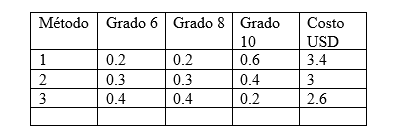



In [ ]:
model = """
# Procesamiento crudo
var metodo1 >= 0;
var metodo2 >= 0;
var metodo3 >= 0;

# Conversión de calidad
var conv_6_a_8 >= 0;
var conv_8_a_10 >= 0;

# Uso en gasolina
var gas_g6 >= 0;
var gas_g8 >= 0;
var gas_g10 >= 0;

# Uso en aceite
var ace_g6 >= 0;
var ace_g8 >= 0;
var ace_g10 >= 0;

# Desecho
var des_g6 >= 0;
var des_g8 >= 0;
var des_g10 >= 0;

maximize ganancia:
    8*(gas_g6 + gas_g8 + gas_g10)
    + 6*(ace_g6 + ace_g8 + ace_g10)
    - 3.4*metodo1 - 3*metodo2 - 2.6*metodo3
    - 1.3*conv_6_a_8 - 2*conv_8_a_10
    - 0.2*(des_g6 + des_g8 + des_g10);

s.t.
balance_g6:
    0.2*metodo1 + 0.3*metodo2 + 0.4*metodo3
    = conv_6_a_8 + gas_g6 + ace_g6 + des_g6;

balance_g8:
    0.2*metodo1 + 0.3*metodo2 + 0.4*metodo3 + conv_6_a_8
    = conv_8_a_10 + gas_g8 + ace_g8 + des_g8;

balance_g10:
    0.6*metodo1 + 0.4*metodo2 + 0.2*metodo3 + conv_8_a_10
    = gas_g10 + ace_g10 + des_g10;

calidad_gasolina:
    6*gas_g6 + 8*gas_g8 + 10*gas_g10 >= 9*(gas_g6 + gas_g8 + gas_g10);

calidad_aceite:
    6*ace_g6 + 8*ace_g8 + 10*ace_g10 >= 7*(ace_g6 + ace_g8 + ace_g10);

limite_gasolina:
    gas_g6 + gas_g8 + gas_g10 <= 2000;

limite_aceite:
    ace_g6 + ace_g8 + ace_g10 <= 600;
"""

In [ ]:
ampl.reset()
ampl.eval(model)
ampl.set_option("solver", "highs")
ampl.solve()

HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 11230
9 simplex iterations
0 barrier iterations


In [ ]:
ampl.display(
    'metodo1', 'metodo2', 'metodo3',
    'conv_6_a_8', 'conv_8_a_10',
    'gas_g6', 'gas_g8', 'gas_g10',
    'ace_g6', 'ace_g8', 'ace_g10',
    'des_g6', 'des_g8', 'des_g10',
    'ganancia'
)

metodo1 = 0
metodo2 = 2400
metodo3 = 200
conv_6_a_8 = 500
conv_8_a_10 = 0
gas_g6 = 0
gas_g8 = 1000
gas_g10 = 1000
ace_g6 = 300
ace_g8 = 300
ace_g10 = 0
des_g6 = 0
des_g8 = 0
des_g10 = 0
ganancia = 11230



### Análisis de los resultados
El modelo mezcla los distintos grados de forma exacta para cumplir justo con la calidad requerida, sin generar exceso.

Restricciones importantes:

* La calidad de gasolina y aceite se cumple justo en el mínimo requerido.
* Se evita generar desecho, ya que tiene costo.

Sensibilidad:
Si sube el precio de la gasolina, el modelo tendería a usar métodos que produzcan más grado 10, aunque sean más caros.

#Cuarto Problema
Donovan Enterprises fabrica licuadoras. Durante los cuatro trimestres siguientes se tiene que cumplir (a tiempo) con la siguiente demanda de licuadoras: trimestre 1, 4 000; trimestre 2, 2 000; trimestre 3, 3 000; trimestre 4, 10 000. Cada empleado de Donovan trabaja tres trimestres del año y tiene un trimestre libre. Por consiguiente, un empleado podría trabajar durante los trimestres 1, 2 y 4, y tener libre el trimestre 3. Cada empleado recibe un salario de 30 000 dólares al año, y (si trabaja) produce hasta 500 licuadoras en un trimestre. Al final de cada trimestre, Donovan incurre en un costo por guardar los artículos de 30 dólares por unidad sobre cada licuadora en inventario. Plantee un PL para ayudar a Donovan a minimizar los costos (mano de obra e inventario) en el cumplimiento (a tiempo) de la demanda del año próximo. Hay en existencia 600 licuadoras a principios del trimestre 1."



In [ ]:
model = """
# Empleados que descansan por trimestre (también deben ser enteros)
var descansa_T1 integer >= 0;
var descansa_T2 integer >= 0;
var descansa_T3 integer >= 0;
var descansa_T4 integer >= 0;

# Inventario (puede ser continuo)
var inv_T1 >= 0;
var inv_T2 >= 0;
var inv_T3 >= 0;
var inv_T4 >= 0;

# Total empleados (entero)
var empleados integer >= 0;

minimize costo_total:
    30000*empleados + 30*(inv_T1 + inv_T2 + inv_T3 + inv_T4);

s.t.
total_empleados:
    empleados = descansa_T1 + descansa_T2 + descansa_T3 + descansa_T4;

balance_T1:
    600 + 500*(empleados - descansa_T1) = 4000 + inv_T1;

balance_T2:
    inv_T1 + 500*(empleados - descansa_T2) = 2000 + inv_T2;

balance_T3:
    inv_T2 + 500*(empleados - descansa_T3) = 3000 + inv_T3;

balance_T4:
    inv_T3 + 500*(empleados - descansa_T4) = 10000 + inv_T4;
"""

In [ ]:
ampl.reset()
ampl.eval(model)
ampl.set_option("solver", "highs")
ampl.solve()

HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 597000
4 simplex iterations
1 branching nodes


In [ ]:
ampl.display(
    'empleados',
    'descansa_T1', 'descansa_T2', 'descansa_T3', 'descansa_T4',
    'inv_T1', 'inv_T2', 'inv_T3', 'inv_T4',
    'costo_total'
)

empleados = 13
descansa_T1 = 6
descansa_T2 = 7
descansa_T3 = 0
descansa_T4 = 0
inv_T1 = 100
inv_T2 = 1100
inv_T3 = 4600
inv_T4 = 1100
costo_total = 597000



### Análisis de los resultados
El modelo produce más en los trimestres 2 y 3 y guarda inventario para cubrir la alta demanda del trimestre 4.

Restricciones importantes:
* La gran demanda en el trimestre 4 es el principal desafío.
* Los empleados son limitados y trabajan solo 3 trimestres.

Sensibilidad:
Si el costo de almacenamiento aumentara, el modelo preferiría contratar más empleados en lugar de guardar tanto inventario.

#Quinto Problema
Un grupo de investigación de mercado necesita detectar por lo menos a 150 esposas, 120 esposos, 100 varones adultos solteros y 110 mujeres adultas solteras mediante una encuesta telefónica. Cuesta 2 dólares hacer una llamada en el día y (debido a los costos de mano de obra más altos) 5 dólares una llamada por la noche. Los resultados se dan en la tabla. Debido a que el personal es limitado, cuando mucho la mitad de todas las llamadas pueden ser nocturnas. Plantee un PL para minimizar el costo de completar la encuesta."
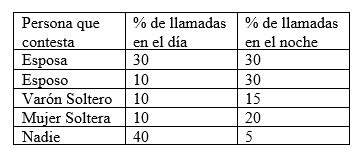


In [ ]:
model = """

var llamadas_dia >= 0;
var llamadas_noche >= 0;

minimize costo_total:
    2*llamadas_dia + 5*llamadas_noche;

s.t.
esposas:
    0.3*llamadas_dia + 0.3*llamadas_noche >= 150;

esposos:
    0.1*llamadas_dia + 0.3*llamadas_noche >= 120;

hombres_solteros:
    0.1*llamadas_dia + 0.15*llamadas_noche >= 100;

mujeres_solteras:
    0.1*llamadas_dia + 0.2*llamadas_noche >= 110;

limite_nocturnas:
    llamadas_noche <= 0.5*(llamadas_dia + llamadas_noche);
"""

In [ ]:
ampl.reset()
ampl.eval(model)
ampl.set_option("solver", "highs")
ampl.solve()

HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 2300
4 simplex iterations
0 barrier iterations


In [ ]:
ampl.display('llamadas_dia', 'llamadas_noche', 'costo_total')

llamadas_dia = 900
llamadas_noche = 100
costo_total = 2300



### Análisis de los resultados
Se realizan la mayoría de las llamadas durante el día (más baratas) y solo algunas de noche.

Restricciones importantes:
* Algunos grupos (como esposos y mujeres solteras) tienen baja tasa de respuesta de día, lo que obliga a hacer llamadas nocturnas.
* La restricción de máximo 50% de llamadas nocturnas no afecta en este caso.

Sensibilidad:
Si el costo de las llamadas nocturnas bajara, se usarían más.

#Sexto Problema
Brady Corporation fabrica alacenas. Requiere cada semana 90 000 pies cúbicos de tablones. La compañía puede conseguir madera de dos maneras: primero, la podría comprar con un proveedor y secarla en el horno del proveedor. Segundo, podría cortar troncos en sus propios terrenos, cortarlos en tablones en su aserradero y, por último, secarlos en su propio horno. Compra y Calidad de Tablones: Brady puede comprar tablones grado 1 o grado 2. Los tablones grado 1 cuestan 3 dólares por pie cúbico, y cuando se secan rinden 0.7 pies cúbicos de madera útil. Los tablones grado 2 cuestan 7 dólares el pie cúbico, y luego de secarlos rinden 0.9 pies cúbicos de madera útil.
Procesamiento de Troncos Propios: A la compañía le cuesta 3 dólares cortar los troncos. Después de cortar y secar un tronco, éste rinde 0.8 pies cúbicos de tablones. Costos de Operación: Brady gasta 4 dólares por pie cúbico de tablones secados. Además, cuesta 2.50 dólares por pie cúbico de troncos enviados al aserradero. Capacidades y Restricciones: El aserradero puede procesar cada semana hasta 35 000 pies cúbicos de tablones. Se pueden comprar cada semana hasta 40 000 pies cúbicos de tablones grado 1 y hasta 60 000 pies cúbicos del grado 2. Se dispone cada semana de 40 h para secar los tablones. Tiempos de Secado: El tiempo que se requiere para secar 1 pie cúbico de madera es el siguiente: Grado 1: 1.2 segundos (s).Grado 2: 0.8 s. Troncos: 1.3 s. Determine un PL (Programación Lineal) que ayude a Brady a minimizar el costo a la semana por cumplir con la demanda de tablones procesados.


In [ ]:
model = """
var compra_grado1 >= 0;
var compra_grado2 >= 0;
var troncos_propios >= 0;

minimize costo_total:
    3*compra_grado1 + 7*compra_grado2
    + 3*troncos_propios + 2.5*troncos_propios
    + 4*(0.7*compra_grado1 + 0.9*compra_grado2 + 0.8*troncos_propios);

s.t.
demanda_madera:
    0.7*compra_grado1 + 0.9*compra_grado2 + 0.8*troncos_propios >= 90000;

limite_grado1:
    compra_grado1 <= 40000;

limite_grado2:
    compra_grado2 <= 60000;

capacidad_aserradero:
    troncos_propios <= 35000;

tiempo_secado:
    1.2*compra_grado1 + 0.8*compra_grado2 + 1.3*troncos_propios <= 40*3600;
"""

In [ ]:
ampl.reset()
ampl.eval(model)
ampl.set_option("solver", "highs")
ampl.solve()

HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 936944.4444
0 simplex iterations
0 barrier iterations


In [ ]:
ampl.display('compra_grado1', 'compra_grado2', 'troncos_propios', 'costo_total')

compra_grado1 = 40000
compra_grado2 = 37777.8
troncos_propios = 35000
costo_total = 936944



### Análisis de los resultados
Se priorizan las opciones más baratas (grado 1 y producción propia) y solo se usa grado 2 cuando es necesario.

Restricciones importantes:

* Se alcanza el límite de compra de grado 1 y la capacidad del aserradero.
* Por eso se debe recurrir a madera grado 2, aunque es más cara.

Sensibilidad:
Si se pudiera aumentar la capacidad del aserradero, los costos bajarían bastante, ya que se evitaría comprar madera cara.

#Séptimo Problema
Un centro de reciclaje industrial utiliza dos chatarras de aluminio, A y B, para producir una aleación especial. La chatarra A contiene 6% de aluminio, 3% de silicio, y 4% de carbón. La chatarra B contiene 3% de aluminio, 6% de silicio, y 3% de carbón. Los costos por tonelada de las chatarras A y B son de $100 y $80, respectivamente. Las especificaciones de la aleación especial requieren que (1) el contenido de aluminio debe ser mínimo de 3% y máximo de 6%; (2) el contenido de silicio debe ser de entre 3 y 5%, y (3) el contenido de carbón debe ser de entre 3 y 7%. Determine la mezcla óptima de las chatarras que deben usarse para producir 1000 toneladas de la aleación.

In [ ]:
model = """
var chatarra_A >= 0;
var chatarra_B >= 0;

minimize costo_total:
    100*chatarra_A + 80*chatarra_B;

s.t.
total_mezcla:
    chatarra_A + chatarra_B = 1000;

aluminio_min:
    0.06*chatarra_A + 0.03*chatarra_B >= 30;

aluminio_max:
    0.06*chatarra_A + 0.03*chatarra_B <= 60;

silicio_min:
    0.03*chatarra_A + 0.06*chatarra_B >= 30;

silicio_max:
    0.03*chatarra_A + 0.06*chatarra_B <= 50;

carbono_min:
    0.04*chatarra_A + 0.03*chatarra_B >= 30;

carbono_max:
    0.04*chatarra_A + 0.03*chatarra_B <= 70;
"""

In [ ]:
ampl.reset()
ampl.eval(model)
ampl.set_option("solver", "highs")
ampl.solve()

HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 86666.66667
0 simplex iterations
0 barrier iterations


In [ ]:
ampl.display('chatarra_A', 'chatarra_B', 'costo_total')

chatarra_A = 333.333
chatarra_B = 666.667
costo_total = 86666.7



### Análisis de los resultados
Se usa la mayor cantidad posible de chatarra B (más barata) y se mezcla con chatarra A para cumplir las restricciones.

Restricciones importantes:

* El silicio es el factor limitante, ya que la chatarra B tiene mucho.
* Por eso se agrega chatarra A para equilibrar la mezcla.

Sensibilidad:
Si se permitiera un mayor porcentaje de silicio, se podría usar más chatarra B y reducir costos.